In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_parquet("dataDumper.parquet")
df.columns

Index(['Time_utc', 'VehicleName', 'VehicleType', 'Pressure_Pa_1',
       'Pressure_Pa_2', 'Pressure_Pa_3', 'Pressure_Pa_4', 'Pressure_Pa_5',
       'Pressure_Pa_6', 'Temperature_K_1', 'Temperature_K_2',
       'Temperature_K_3', 'Temperature_K_4', 'Temperature_K_5',
       'Temperature_K_6', 'ColdPressure_Pa_1', 'ColdPressure_Pa_2',
       'ColdPressure_Pa_3', 'ColdPressure_Pa_4', 'ColdPressure_Pa_5',
       'ColdPressure_Pa_6', 'Latitude_dd', 'Longitude_dd', 'Altitude_m',
       'Speed_mps', 'epsilonX', 'epsilonY', 'epsilonZ', 'epsilonSpeed',
       'AtmosphericPressure_Pa', 'dt_s', 'dd_m', 'RatioPayload'],
      dtype='object')

In [ ]:
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201312 entries, 0 to 201311
Data columns (total 33 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Time_utc                201312 non-null  object 
 1   VehicleName             201312 non-null  object 
 2   VehicleType             201312 non-null  object 
 3   Pressure_Pa_1           198245 non-null  float64
 4   Pressure_Pa_2           201106 non-null  float64
 5   Pressure_Pa_3           201190 non-null  float64
 6   Pressure_Pa_4           201088 non-null  float64
 7   Pressure_Pa_5           201178 non-null  float64
 8   Pressure_Pa_6           201158 non-null  float64
 9   Temperature_K_1         198245 non-null  float64
 10  Temperature_K_2         201106 non-null  float64
 11  Temperature_K_3         201190 non-null  float64
 12  Temperature_K_4         201088 non-null  float64
 13  Temperature_K_5         201178 non-null  float64
 14  Temperature_K_6     

Time_utc                     0
VehicleName                  0
VehicleType                  0
Pressure_Pa_1             3067
Pressure_Pa_2              206
Pressure_Pa_3              122
Pressure_Pa_4              224
Pressure_Pa_5              134
Pressure_Pa_6              154
Temperature_K_1           3067
Temperature_K_2            206
Temperature_K_3            122
Temperature_K_4            224
Temperature_K_5            134
Temperature_K_6            154
ColdPressure_Pa_1         3067
ColdPressure_Pa_2          206
ColdPressure_Pa_3          122
ColdPressure_Pa_4          224
ColdPressure_Pa_5          134
ColdPressure_Pa_6          154
Latitude_dd                  0
Longitude_dd                 0
Altitude_m                   0
Speed_mps                    0
epsilonX                     0
epsilonY                     0
epsilonZ                     0
epsilonSpeed                 0
AtmosphericPressure_Pa     957
dt_s                         0
dd_m                      2634
RatioPay

In [19]:
df['RatioPayload'] = df['RatioPayload'].ffill().bfill()

gps_cols = ['Latitude_dd', 'Longitude_dd', 'Altitude_m']
df[gps_cols] = df[gps_cols].interpolate(method='linear', limit_direction='both')

pressure_cols = [col for col in df.columns if "Pressure_Pa_" in col]
temperature_cols = [col for col in df.columns if "Temperature_K_" in col]
cold_pressure_cols = [col for col in df.columns if "ColdPressure_Pa_" in col]

df[pressure_cols] = df[pressure_cols].interpolate(method='linear', limit_direction='both')
df[temperature_cols] = df[temperature_cols].interpolate(method='linear', limit_direction='both')
df[cold_pressure_cols] = df[cold_pressure_cols].interpolate(method='linear', limit_direction='both')

motion_cols = ['Speed_mps', 'dd_m', 'epsilonX', 'epsilonY', 'epsilonZ', 'epsilonSpeed']
df[motion_cols] = df[motion_cols].interpolate(method='linear', limit_direction='both')

df['AtmosphericPressure_Pa'] = df['AtmosphericPressure_Pa'].interpolate(method='linear', limit_direction='both')

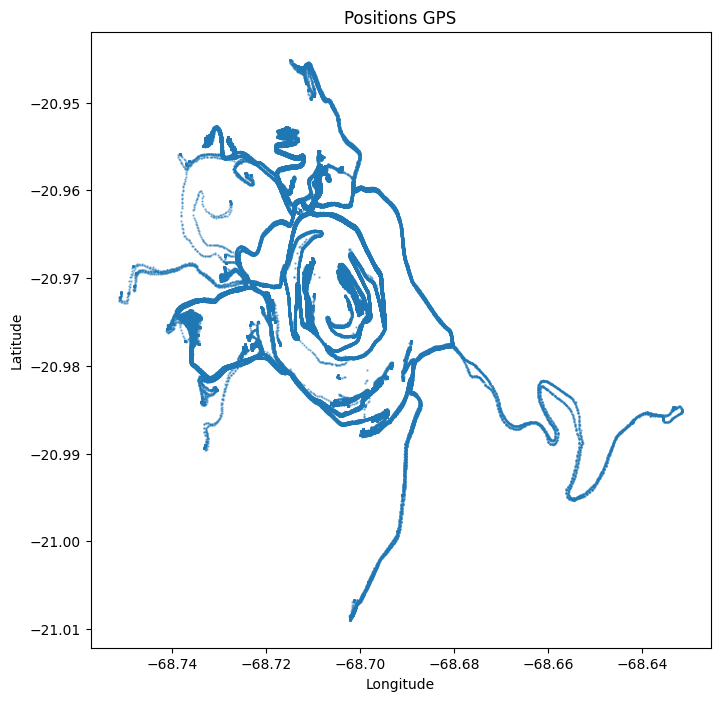

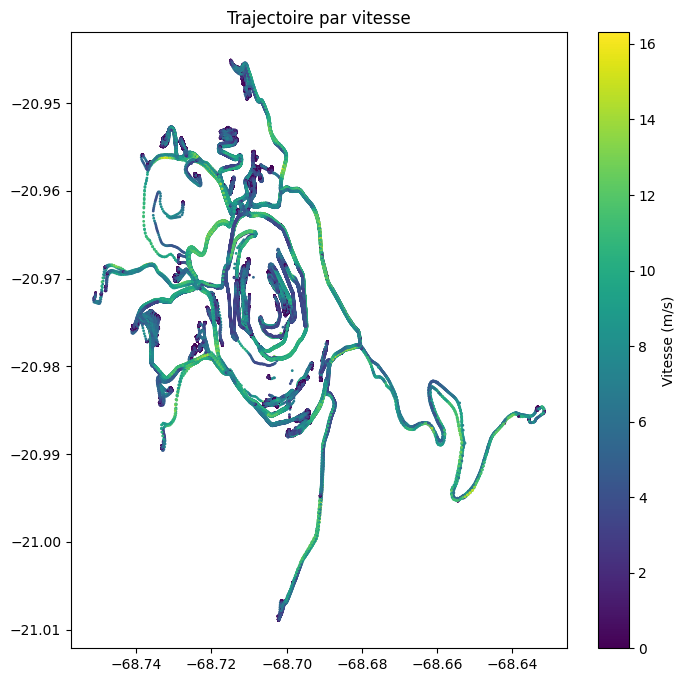

In [23]:
#  Trajctoires globale
plt.figure(figsize=(8,8))
plt.scatter(df['Longitude_dd'], df['Latitude_dd'], s=0.5, alpha=0.5)
plt.title('Positions GPS')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Trajectoire avec vitesse
plt.figure(figsize=(8,8))
plt.scatter(df['Longitude_dd'], df['Latitude_dd'], c=df['Speed_mps'], s=1, cmap='viridis')
plt.colorbar(label='Vitesse (m/s)')
plt.title('Trajectoire par vitesse')
plt.show()

In [25]:
# Nombre de points par phase (vide vs chargé)
counts_by_payload = df['RatioPayload'].value_counts()
print("Nombre de points par phase (RatioPayload) :")
print(counts_by_payload)

# Vitesse moyenne selon charge
speed_by_payload = df.groupby('RatioPayload')['Speed_mps'].mean()
print("\nVitesse moyenne selon charge :")
print(speed_by_payload)


Nombre de points par phase (RatioPayload) :
RatioPayload
0.0    130924
1.0     70388
Name: count, dtype: int64

Vitesse moyenne selon charge :
RatioPayload
0.0    2.721171
1.0    4.306206
Name: Speed_mps, dtype: float64


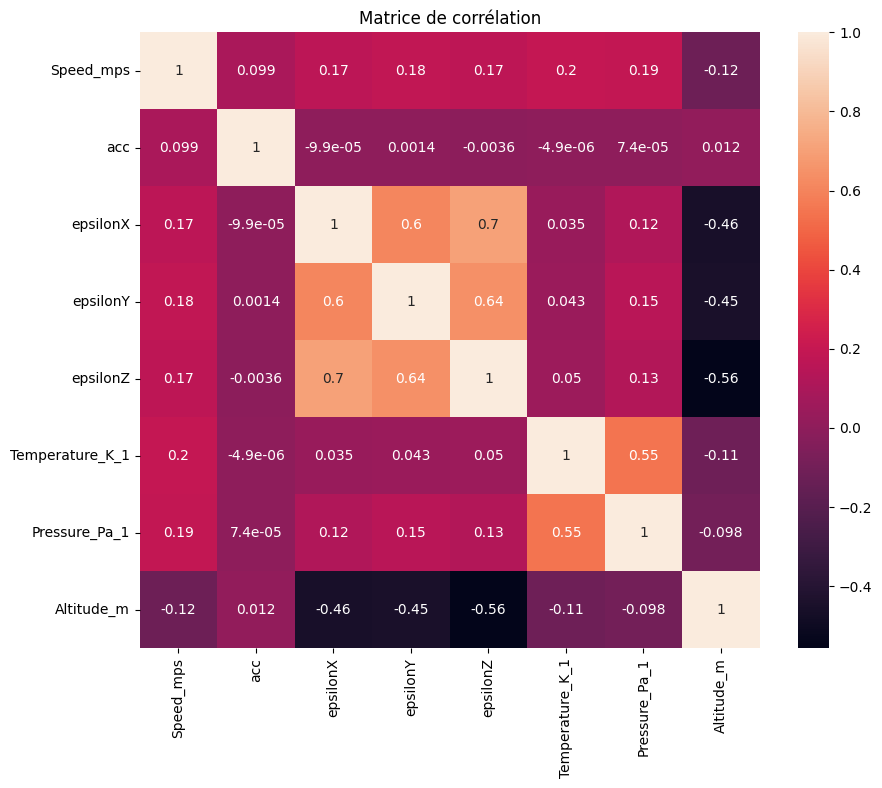

In [28]:
cols_corr = ['Speed_mps', 'acc', 'epsilonX', 'epsilonY', 'epsilonZ', 
             'Temperature_K_1', 'Pressure_Pa_1', 'Altitude_m']

plt.figure(figsize=(10,8))
sns.heatmap(df[cols_corr].corr(), annot=True)
plt.title('Matrice de corrélation')
plt.show()


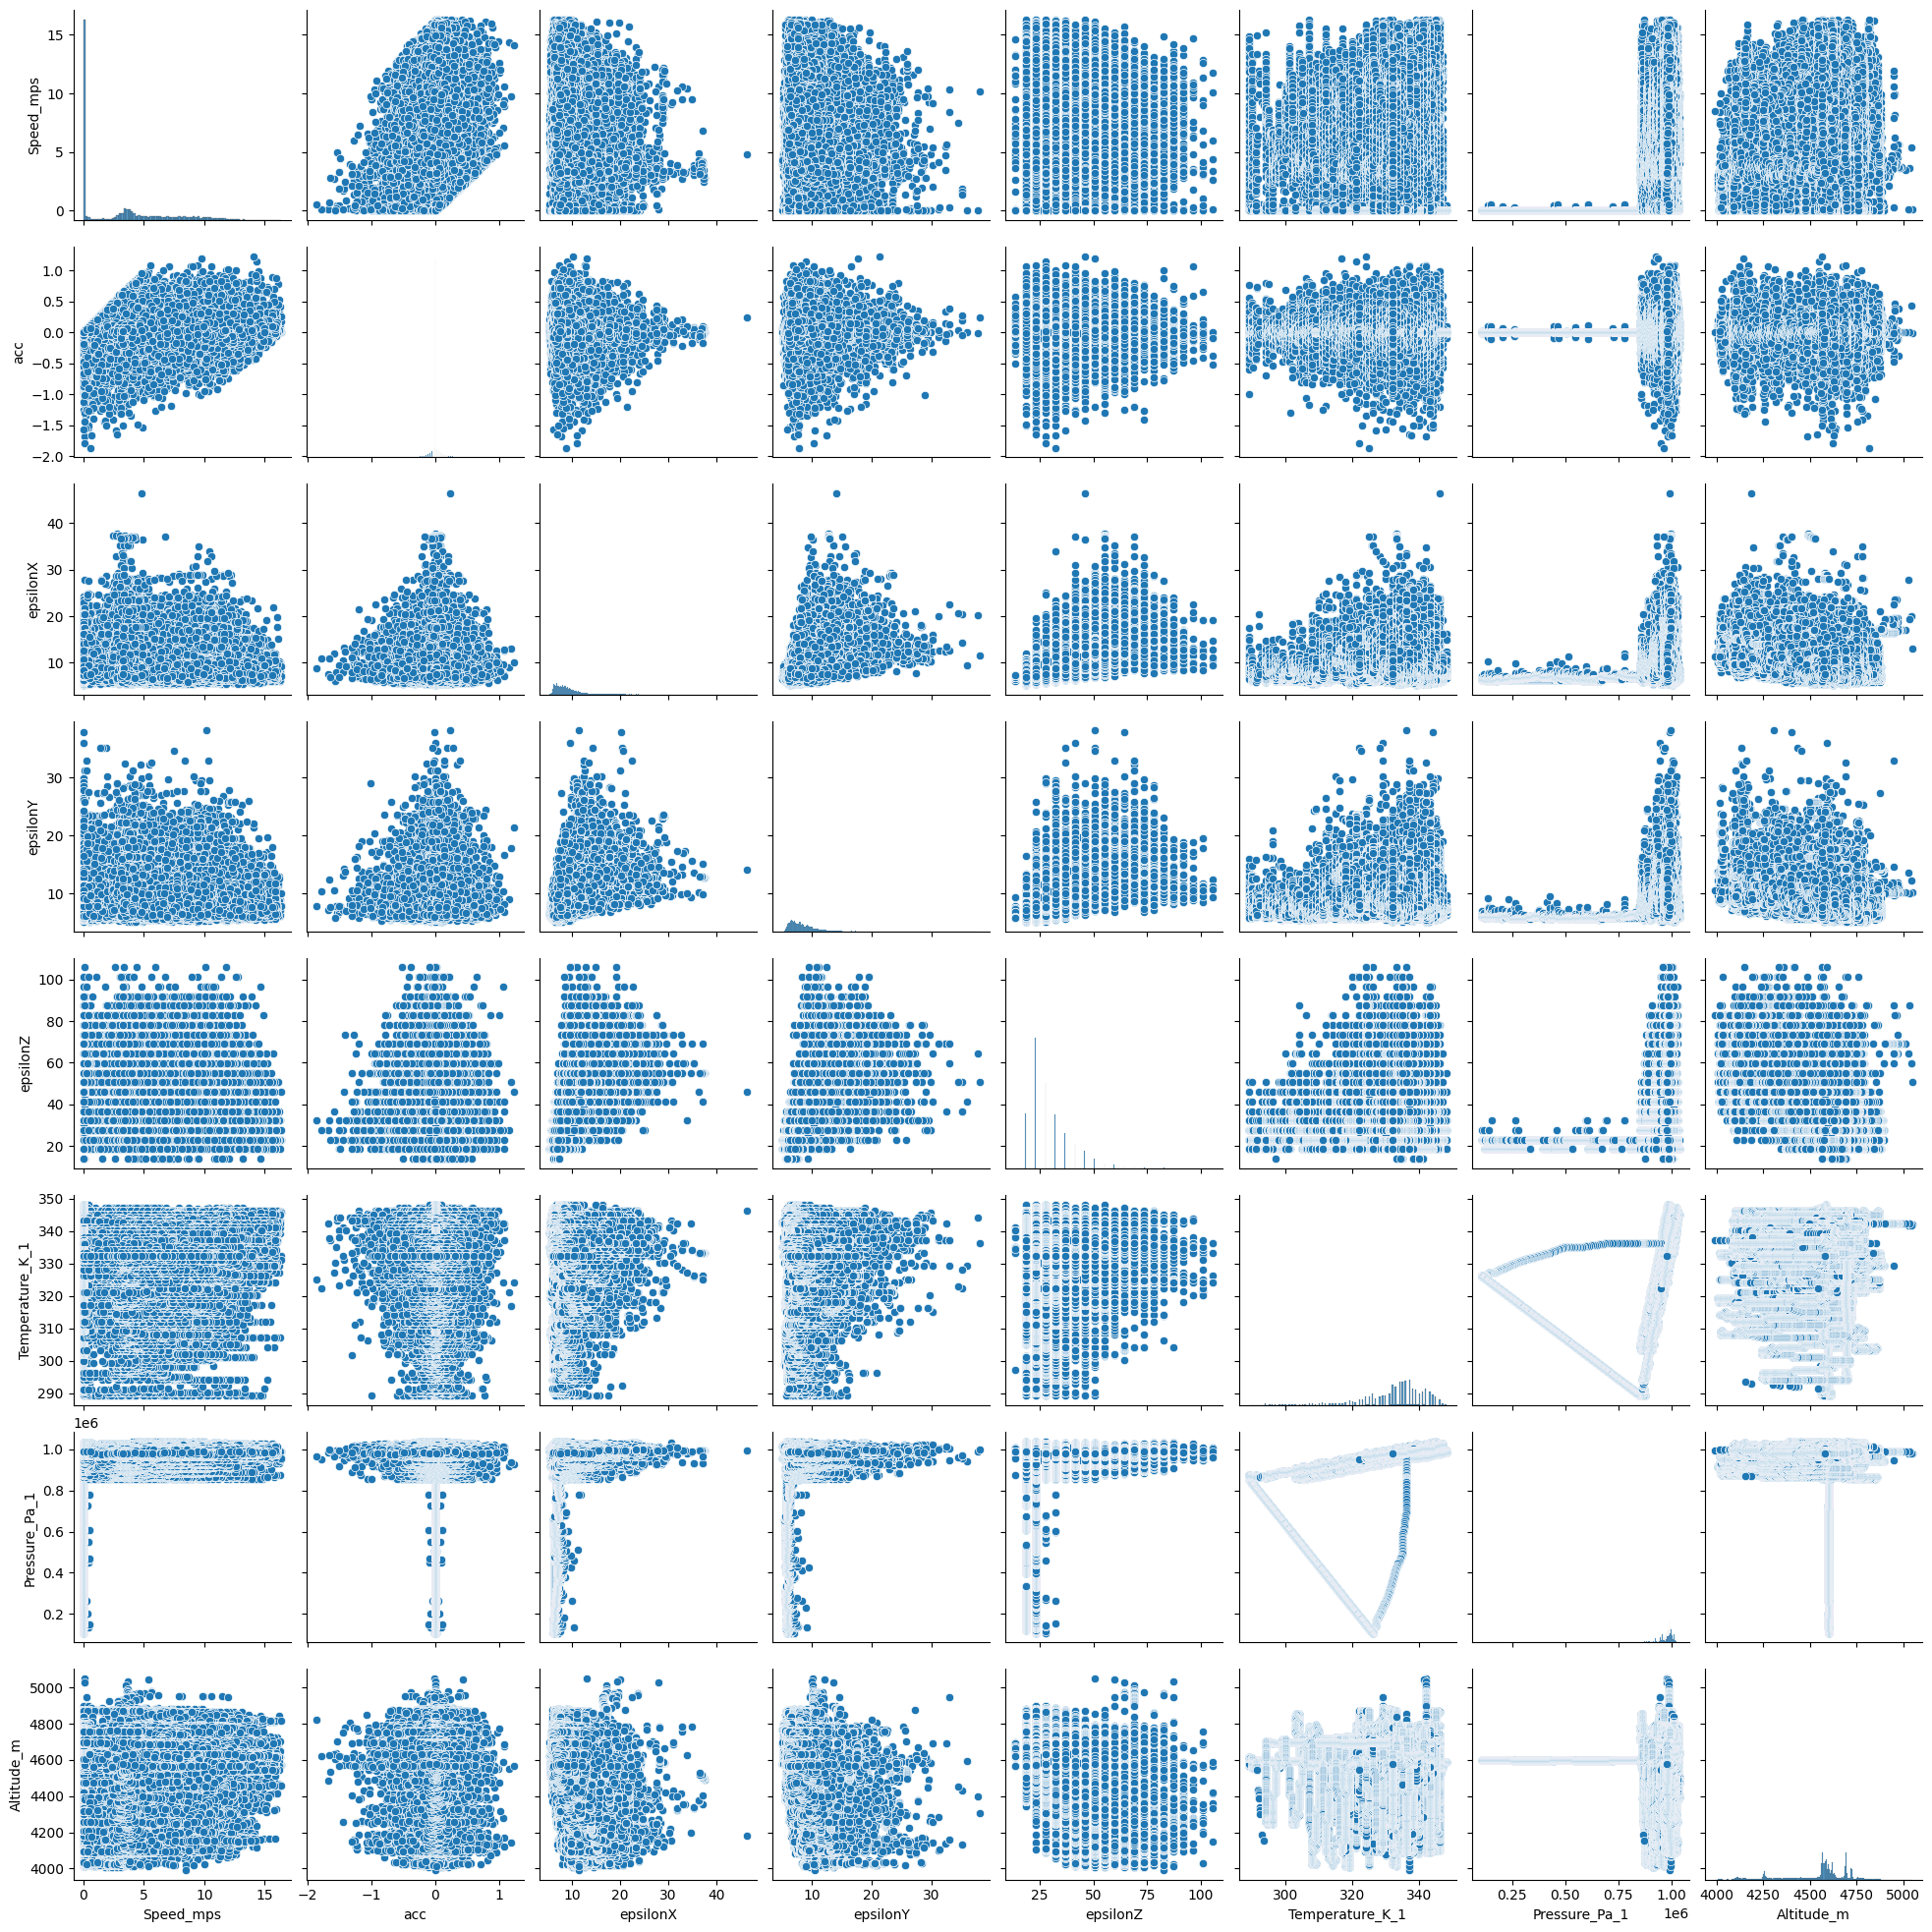

In [33]:
sns.pairplot(df[['Speed_mps', 'acc', 'epsilonX', 'epsilonY', 'epsilonZ','Temperature_K_1', 'Pressure_Pa_1', 'Altitude_m']])
plt.show()
